# 0.31 — EDGAR coverage audit for the US ticker universe

Before running theme backtests on SEC filings, audit what we can actually get.
Three questions, for `ticker_list_US.csv` (8,944 Bloomberg names):

1. **Resolution** — which tickers map to an SEC filer (CIK) at all, and what are the
   ones that don't?
2. **Retrieval by date** — given an as-of date, for how much of the universe can we
   fetch a 10-K/10-Q filed in the prior year?
3. **History depth** — how far back does per-company filing retrieval go?

**Two different backbones, two different floors.**
- *Retrieval*: EDGAR's quarterly **master indexes** list every filing since **1993**
  (electronic filing phased in 1993–95, mandatory 1996). Given (CIK, date) we can always
  enumerate and download the filings — `theme_basket.filing_index()` /
  `filings_asof()`.
- *Search*: EDGAR **full-text search** (what the basket shortlister uses) only covers
  filings since **2001**.

So a backtest can *retrieve* filings for any date ≥ ~1996, but can only *search* them
from 2001 — themes older than that would need local scanning of downloaded filings.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import theme_basket as tb

pd.set_option("display.width", 200)
OUT = Path.cwd().parent / "data" / "processed"


## 1 · Resolution: Bloomberg tickers → SEC CIKs

SEC's `company_tickers.json` maps **current registrants only**. Whatever doesn't
resolve is (a) a security type that never files 10-Ks (ETF shares, SPAC units,
warrants, rights), or (b) a **delisted/renamed company** — the point-in-time gap a
proper backtest must eventually fix with a historical ticker→CIK map.

In [2]:
universe = tb.load_universe()
cik_map = tb.load_cik_map()
by_cik, unresolved = tb.resolve_universe(universe, cik_map)
resolved_tickers = {t for t, _ in by_cik.values()}

def classify(t):
    if t.endswith("-U"):
        return "SPAC unit (-U)"
    if t.endswith(("-WS", "-W", "-WT")):
        return "warrant (-W/-WS)"
    if t.endswith("-R"):
        return "right (-R)"
    return "delisted / ETF / other"

unres = pd.Series([classify(t) for t in unresolved]).value_counts()
print(f"tickers in list          : {len(universe):,}")
print(f"resolved to a CIK        : {sum(t in cik_map for t in universe):,} tickers "
      f"-> {len(by_cik):,} distinct issuers (share classes collapse)")
print(f"unresolved               : {len(unresolved):,}")
print()
print(unres.to_string())
print()
print("unresolved sample:", unresolved[:12])

tickers in list          : 8,945
resolved to a CIK        : 4,423 tickers -> 4,408 distinct issuers (share classes collapse)
unresolved               : 4,522

delisted / ETF / other    4275
SPAC unit (-U)             246
warrant (-W/-WS)             1

unresolved sample: ['AAAP', 'AABA', 'AACC', 'AACQU', 'AACT-U', 'AADI', 'AAI', 'AAIC', 'AAM-U', 'AAMRQ', 'AAN', 'AAQC']


## 2 · The filing backbone: every 10-K/10-Q since 1993

`filing_index()` concatenates EDGAR's quarterly master indexes (10-K*/10-Q* rows,
including legacy variants 10-K405/10-KSB), cached per quarter under
`data/raw/edgar/full_index/`.

In [3]:
idx = tb.filing_index(verbose=False)
print(f"{len(idx):,} filings, {idx.cik.nunique():,} distinct filers, "
      f"{idx.date.min().date()} .. {idx.date.max().date()}")
print(idx.form.value_counts().head(8).to_string())

1,072,432 filings, 43,358 distinct filers, 1993-08-13 .. 2026-07-10
form
10-Q         712773
10-K         238684
10-K/A        48028
10-Q/A        47278
10-K405       21277
10-K405/A      3349
10-KT           610
10-QT           247


In [4]:
uni_ciks = set(by_cik)
uidx = idx[idx.cik.isin(uni_ciks)]
never = uni_ciks - set(uidx.cik.unique())
print(f"universe issuers with >=1 10-K/10-Q ever : {uidx.cik.nunique():,} / {len(uni_ciks):,}")
print(f"resolved but NEVER filed a 10-K/10-Q     : {len(never):,} "
      f"(foreign 20-F filers, funds, trusts, ...)")
print("examples:", sorted(by_cik[c][0] for c in list(never))[:12])

universe issuers with >=1 10-K/10-Q ever : 3,670 / 4,408
resolved but NEVER filed a 10-K/10-Q     : 738 (foreign 20-F filers, funds, trusts, ...)
examples: ['AAC', 'AACG', 'ACCL', 'ACIU', 'ACP', 'ACV', 'ADAG', 'ADSE', 'ADX', 'AEC', 'AER', 'AFYA']


## 3 · History depth: how far back can we go?

Per universe issuer: date of the **first retrievable 10-K/10-Q**. The EDGAR ramp
(1993–96) sets the hard floor; after that the constraint is simply when the company
started filing (IPO).

In [5]:
first = uidx.groupby("cik")["date"].min().dt.year
print("first-retrievable-filing year, universe issuers:")
print(first.value_counts().sort_index().head(12).to_string())
print(f"...\nmedian first year: {int(first.median())}, "
      f"issuers retrievable by 1996: {(first <= 1996).sum():,}")

first-retrievable-filing year, universe issuers:
date
1993      1
1994    378
1995    250
1996    314
1997     73
1998     80
1999     50
2000     59
2001     46
2002     38
2003     24
2004     57
...
median first year: 2011, issuers retrievable by 1996: 943


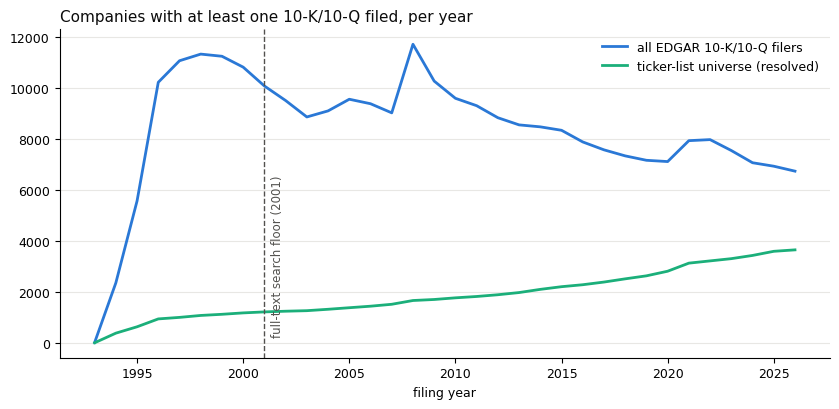

In [6]:
years = range(1993, idx.date.max().year + 1)
all_filers = idx.groupby(idx.date.dt.year)["cik"].nunique()
uni_filers = uidx.groupby(uidx.date.dt.year)["cik"].nunique()

BLUE, AQUA, INK, MUTED = "#2a78d6", "#1baf7a", "#0b0b0b", "#52514e"
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(all_filers.index, all_filers.values, color=BLUE, lw=2, label="all EDGAR 10-K/10-Q filers")
ax.plot(uni_filers.index, uni_filers.values, color=AQUA, lw=2, label="ticker-list universe (resolved)")
ax.axvline(2001, color=MUTED, lw=1, ls="--")
ax.text(2001.3, ax.get_ylim()[1] * 0.02, "full-text search floor (2001)", fontsize=8.5,
        color=MUTED, rotation=90, va="bottom")
ax.set_title("Companies with at least one 10-K/10-Q filed, per year", fontsize=11,
             loc="left", color=INK)
ax.set_xlabel("filing year", fontsize=9)
ax.legend(fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=9)
ax.grid(axis="y", color="#e8e7e4", lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

The universe curve rising toward the present is the **survivorship signature**: the
ticker map resolves today's registrants, so the further back we look, the more of the
then-active market is missing. The *all-EDGAR* curve shows those filings still exist
and are retrievable — what's missing is only our ticker→CIK bridge for dead names.

## 4 · Retrieval by date: coverage of the universe at any as-of

For a grid of as-of dates: share of resolved issuers with ≥1 10-K/10-Q *filed* in the
preceding 365 days (i.e. "we can hand the scorer a reasonably fresh filing").

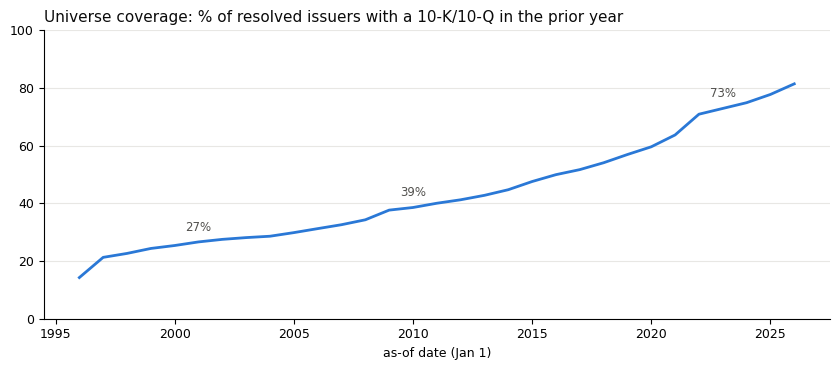

In [7]:
dates = pd.date_range("1996-01-01", idx.date.max(), freq="YS")
cov = []
for d in dates:
    live = uidx[(uidx.date > d - pd.Timedelta(days=365)) & (uidx.date <= d)]["cik"].nunique()
    cov.append(live)
cov = pd.Series(cov, index=dates.year, name="issuers")
covpct = 100 * cov / len(uni_ciks)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(cov.index, covpct.values, color=BLUE, lw=2)
for yr in (2001, 2010, 2023):
    ax.annotate(f"{covpct.loc[yr]:.0f}%", (yr, covpct.loc[yr]), textcoords="offset points",
                xytext=(0, 8), fontsize=8.5, color=MUTED, ha="center")
ax.set_title("Universe coverage: % of resolved issuers with a 10-K/10-Q in the prior year",
             fontsize=11, loc="left", color=INK)
ax.set_xlabel("as-of date (Jan 1)", fontsize=9)
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=9)
ax.grid(axis="y", color="#e8e7e4", lw=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [8]:
# the genAI backtest date, concretely
asof = pd.Timestamp("2023-01-17")
live = uidx[(uidx.date > asof - pd.Timedelta(days=365)) & (uidx.date <= asof)]
live_ciks = set(live.cik.unique())
print(f"as-of {asof.date()}: {len(live_ciks):,} / {len(uni_ciks):,} resolved issuers "
      f"({100 * len(live_ciks) / len(uni_ciks):.0f}%) have a 10-K/10-Q in the prior 365d")
gap = sorted(by_cik[c][0] for c in (set(uidx.cik.unique()) - live_ciks))
print(f"filed historically but NOT in that window: {len(gap):,}  e.g. {gap[:10]}")

as-of 2023-01-17: 3,214 / 4,408 resolved issuers (73%) have a 10-K/10-Q in the prior 365d
filed historically but NOT in that window: 456  e.g. ['AACBU', 'AACIU', 'AARD', 'ADCT', 'ADVB', 'AEAQU', 'AEBI', 'AESI', 'AFJK', 'AII']


## 5 · Spot retrieval: ticker + date → actual documents

`filings_asof()` — the primitive the basket builder rests on.

In [9]:
for t in ("AAPL", "NVDA", "VERI"):
    cik = cik_map[t][0]
    f = tb.filings_asof(idx, cik, "2023-01-17", 365)
    print(f"{t} (CIK {cik}) — {len(f)} filings in [2022-01-17, 2023-01-17]:")
    print(f[["form", "date", "url"]].head(5).to_string(index=False), "\n")

AAPL (CIK 320193) — 4 filings in [2022-01-17, 2023-01-17]:
form       date                                                                     url
10-K 2022-10-28 https://www.sec.gov/Archives/edgar/data/320193/0000320193-22-000108.txt
10-Q 2022-07-29 https://www.sec.gov/Archives/edgar/data/320193/0000320193-22-000070.txt
10-Q 2022-04-29 https://www.sec.gov/Archives/edgar/data/320193/0000320193-22-000059.txt
10-Q 2022-01-28 https://www.sec.gov/Archives/edgar/data/320193/0000320193-22-000007.txt 

NVDA (CIK 1045810) — 4 filings in [2022-01-17, 2023-01-17]:
form       date                                                                      url
10-Q 2022-11-18 https://www.sec.gov/Archives/edgar/data/1045810/0001045810-22-000166.txt
10-Q 2022-08-31 https://www.sec.gov/Archives/edgar/data/1045810/0001045810-22-000147.txt
10-Q 2022-05-27 https://www.sec.gov/Archives/edgar/data/1045810/0001045810-22-000079.txt
10-K 2022-03-18 https://www.sec.gov/Archives/edgar/data/1045810/0001045810-22-00003

## 6 · Per-ticker diagnostic file

One row per ticker in the list: resolution status, CIK, first/last retrievable
10-K/10-Q, filing count — written to `data/processed/universe_edgar_coverage.csv`.

In [10]:
stats = (uidx.groupby("cik")
             .agg(first_filing=("date", "min"), last_filing=("date", "max"),
                  n_filings=("date", "count")))
rows = []
for t in universe:
    if t not in cik_map:
        rows.append({"ticker": t, "status": classify(t) if classify(t) != "delisted / ETF / other"
                     else "unresolved (delisted/ETF/other)", "cik": None})
        continue
    cik, title = cik_map[t]
    s = stats.loc[cik] if cik in stats.index else None
    rows.append({"ticker": t, "cik": cik, "company": title,
                 "status": "ok" if s is not None else "resolved, never filed 10-K/10-Q",
                 "first_filing": None if s is None else s.first_filing.date(),
                 "last_filing": None if s is None else s.last_filing.date(),
                 "n_filings": 0 if s is None else int(s.n_filings)})
diag = pd.DataFrame(rows)
diag.to_csv(OUT / "universe_edgar_coverage.csv", index=False)
print(diag.status.value_counts().to_string())
print(f"\n-> {OUT / 'universe_edgar_coverage.csv'}")
diag[diag.status == "ok"].head(8)

status
unresolved (delisted/ETF/other)    4275
ok                                 3685
resolved, never filed 10-K/10-Q     738
SPAC unit (-U)                      246
warrant (-W/-WS)                      1

-> /Users/albertorumi/Documents/Intesa/ThematicTrading/code/data/processed/universe_edgar_coverage.csv


,ticker,cik,company,status,first_filing,last_filing,n_filings
0,A,1090872.0,"AGILENT TECHNOLOGIES, INC.",ok,2000-01-25,2026-06-01,113.0
1,AA,1675149.0,Alcoa Corp,ok,2016-12-01,2026-04-30,39.0
3,AAAU,1708646.0,Goldman Sachs Physical Gold ETF,ok,2018-11-09,2026-05-11,31.0
6,AACBU,2034334.0,Artius II Acquisition Inc.,ok,2025-05-07,2026-05-06,5.0
9,AACIU,2092897.0,Armada Acquisition Corp. III,ok,2026-03-20,2026-05-08,2.0
15,AAL,6201.0,American Airlines Group Inc.,ok,1994-03-31,2026-04-23,144.0
17,AAMI,1748824.0,Acadian Asset Management Inc.,ok,2019-08-09,2026-05-07,28.0
20,AAOI,1158114.0,"APPLIED OPTOELECTRONICS, INC.",ok,2013-11-14,2026-05-07,59.0


## 7 · Takeaways

- **Retrieval floor ≈ 1996** (EDGAR mandatory e-filing; first universe filings 1993),
  **search floor = 2001** (full-text). The stack can *fetch* filings for any modern-era
  backtest date; it can only *search* them from 2001.
- **Resolution is the binding constraint, and it decays going back**: the SEC ticker
  map covers current registrants only, so universe coverage at an as-of date is
  **73% (2023) → 39% (2010) → 27% (2001)** of resolved issuers — and resolved issuers
  are themselves only half the Bloomberg list. The *all-EDGAR* curve (~10k filers in
  2001) shows the filings exist; what's missing is the ticker→CIK bridge for
  delisted/renamed names. **Backtests before ~2015 need a historical ticker→CIK map**
  (EDGAR former-names data or a vendor mapping) before their baskets can be trusted.
- **738 resolved issuers never file 10-K/10-Q** (foreign 20-F filers like BABA/BIDU,
  funds, trusts) — structurally invisible to a 10-K/10-Q scorer; per-ticker detail in
  `universe_edgar_coverage.csv`.
- At the genAI date (2023-01-17): **3,214 issuers (73%)** had a fresh filing in the
  prior 365 days; 456 resolved issuers had older filings only (mostly SPAC shells and
  recent IPOs mid-cycle).
